# 01 - Exploratory Data Analysis

This notebook covers dataset overview, target balance, missing values, correlation, and visual diagnostics.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loading import load_application_train

sns.set_theme(style='whitegrid', context='notebook')

In [2]:
df = load_application_train(optimize_memory=False)
print(f'Shape: {df.shape}')
print(f'Target mean: {df["TARGET"].mean():.4f}')
df.head()

Shape: (307511, 122)
Target mean: 0.0807


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


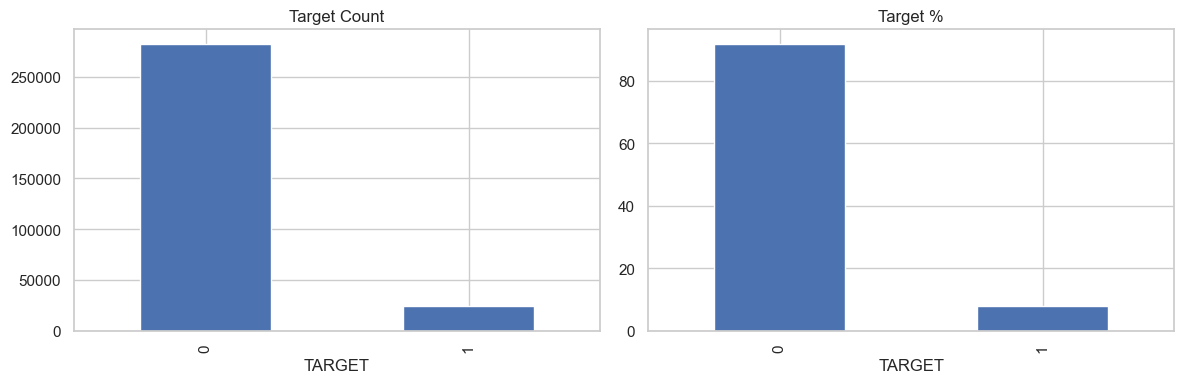

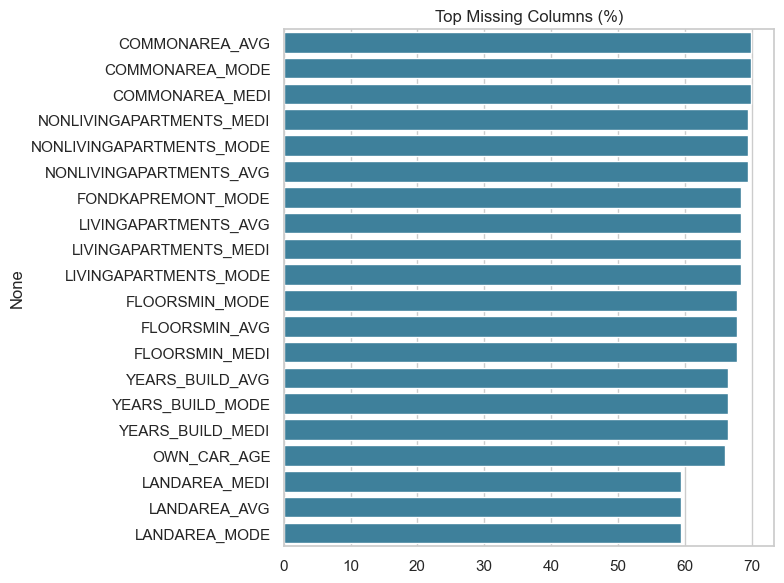

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['TARGET'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Target Count')
(df['TARGET'].value_counts(normalize=True).sort_index() * 100).plot(kind='bar', ax=axes[1], title='Target %')
plt.tight_layout()

missing_pct = df.isna().mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
sns.barplot(x=missing_pct.values * 100, y=missing_pct.index, color='#2E86AB')
plt.title('Top Missing Columns (%)')
plt.tight_layout()

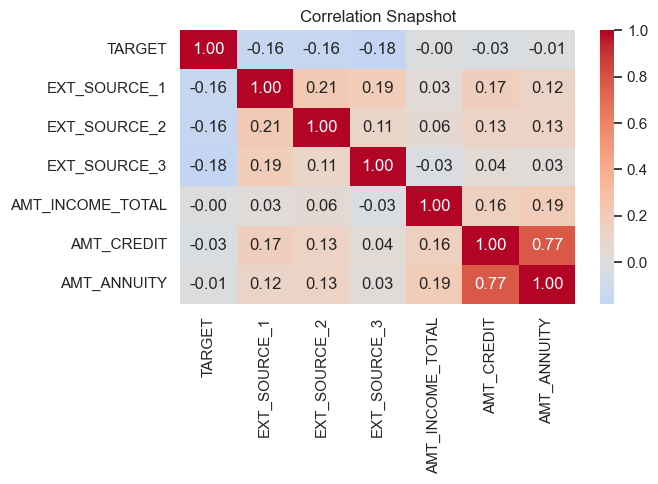

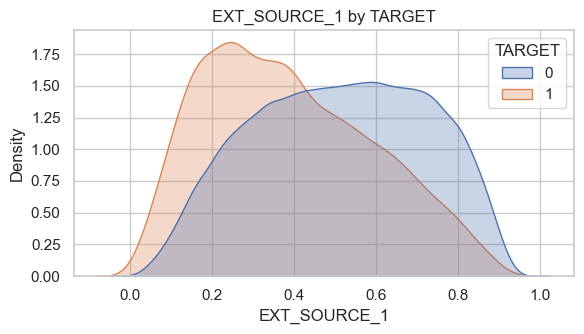

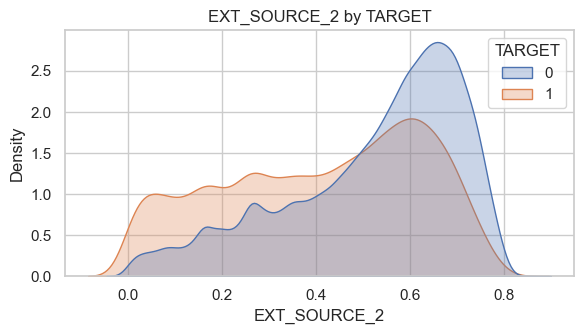

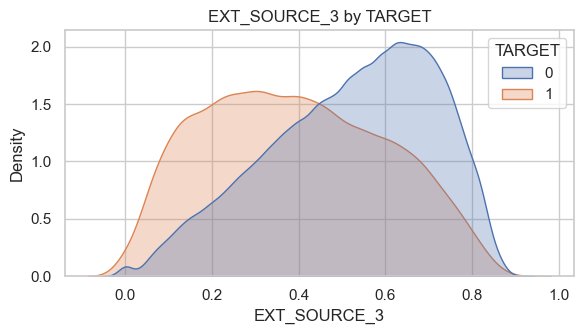

In [4]:
corr_cols = ['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']
corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Correlation Snapshot')
plt.tight_layout()

for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    plt.figure(figsize=(6, 3.5))
    sns.kdeplot(data=df, x=col, hue='TARGET', fill=True, common_norm=False, alpha=0.3)
    plt.title(f'{col} by TARGET')
    plt.tight_layout()